# California Housing Price Prediction
## End-to-End Machine Learning Regression Project

### Objective
The goal of this project is to build a machine learning regression model that predicts the median house value of California neighborhoods using demographic, geographic, and housing-related features.

### Dataset
- Source: California Housing Dataset
- Records: 20,640
- Features: 10
- Target Variable: `median_house_value`

In [124]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

## Phase 1 

In [125]:
df=pd.read_csv('housing.csv')

In [126]:
df.shape

(20640, 10)

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [128]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [129]:
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [130]:
df.tail(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20630,-121.32,39.29,11.0,2640.0,505.0,1257.0,445.0,3.5673,112000.0,INLAND
20631,-121.40,39.33,15.0,2655.0,493.0,1200.0,432.0,3.5179,107200.0,INLAND
20632,-121.45,39.26,15.0,2319.0,416.0,1047.0,385.0,3.1250,115600.0,INLAND
20633,-121.53,39.19,27.0,2080.0,412.0,1082.0,382.0,2.5495,98300.0,INLAND
20634,-121.56,39.27,28.0,2332.0,395.0,1041.0,344.0,3.7125,116800.0,INLAND
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [131]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## 
 The dataset has 20,640 records and includes both numerical and categorical features. I noticed that total_bedrooms contains some missing values, while the other columns are complete. The large variation in house prices and room counts makes me wonder whether there are outliers and how factors like income and location affect the median house value.

# Phase 2 — Exploratory Data Analysis (EDA)

## This is detective work


In [132]:
num_cols=df.select_dtypes(include=['number']).columns

In [133]:
num_cols

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

In [134]:
cat_cols=df.select_dtypes(include=['object']).columns

In [135]:
cat_cols

Index(['ocean_proximity'], dtype='object')

In [136]:
import matplotlib.pyplot as plt


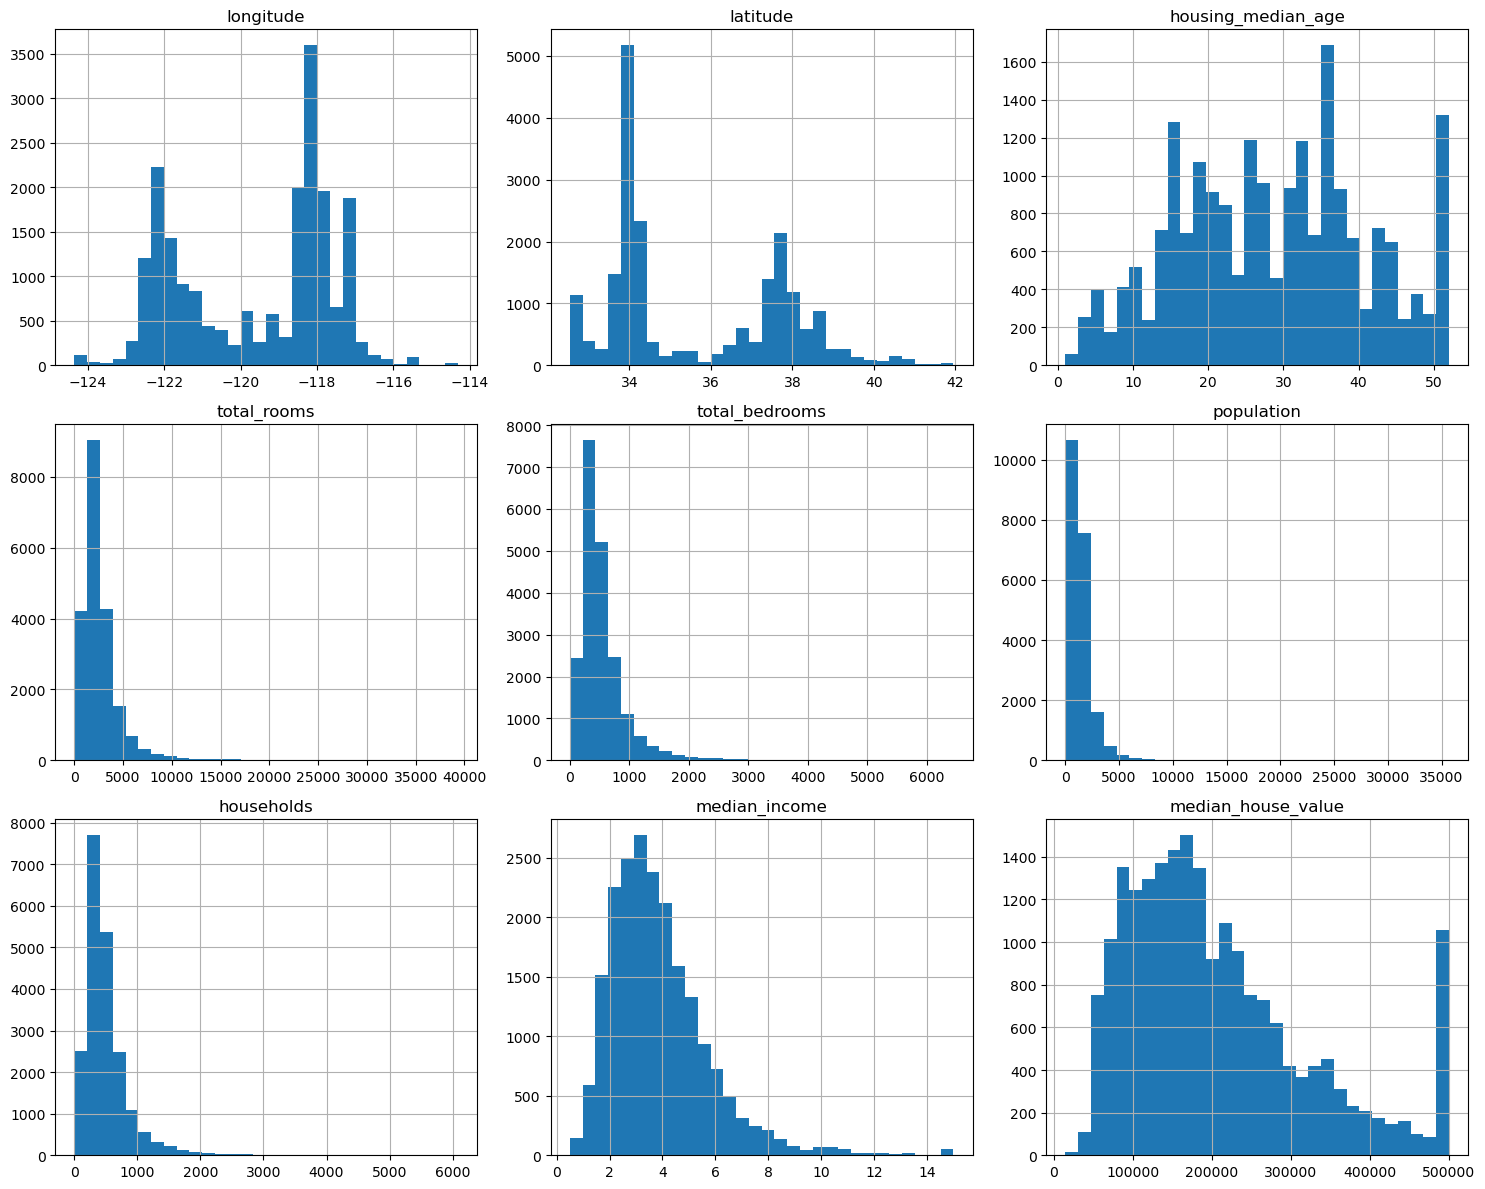

In [137]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

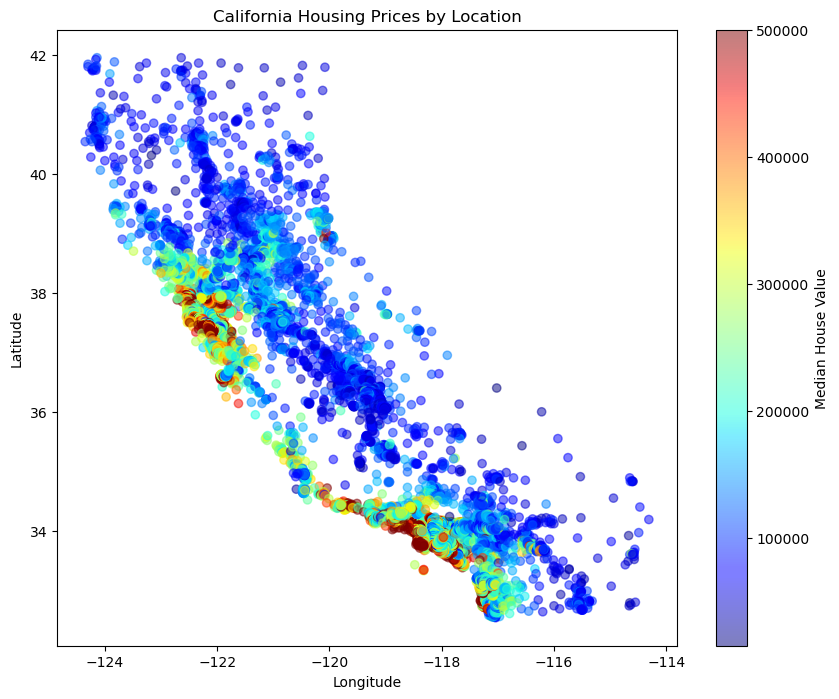

In [138]:
plt.figure(figsize=(10,8))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["median_house_value"],
    cmap="jet",
    alpha=0.5
)

plt.colorbar(label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Prices by Location")
plt.show()

In [139]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

In [140]:
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


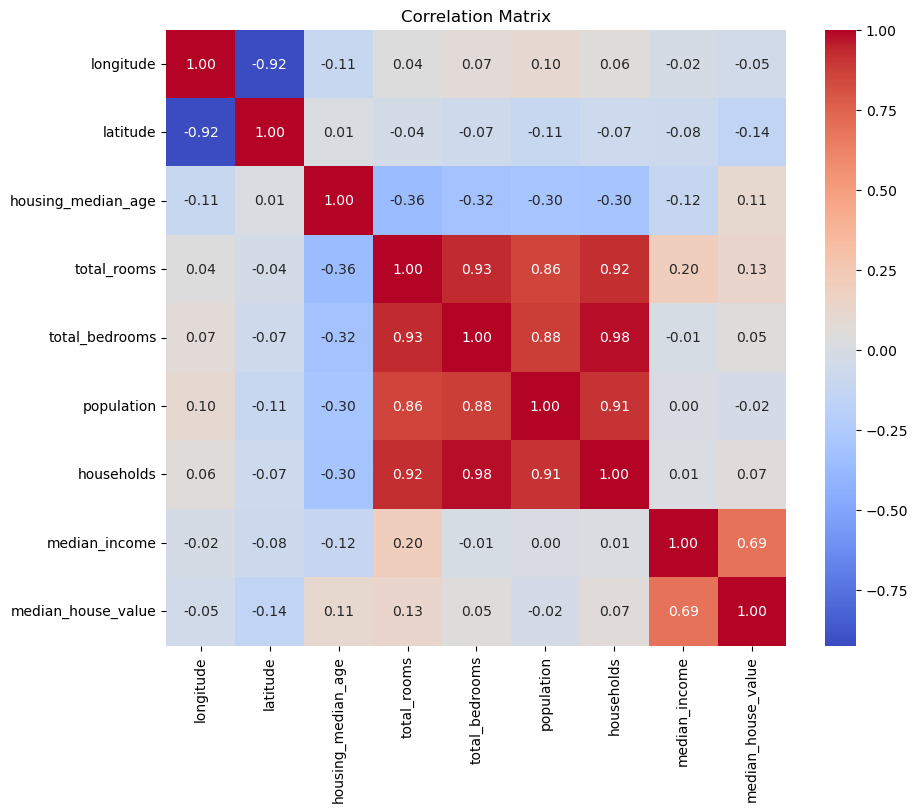

In [141]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [142]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


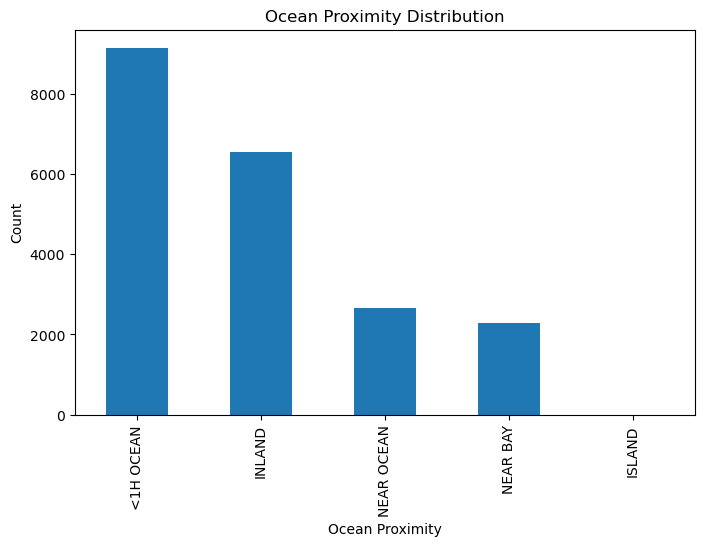

In [143]:
df["ocean_proximity"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Ocean Proximity Distribution")
plt.xlabel("Ocean Proximity")
plt.ylabel("Count")
plt.show()

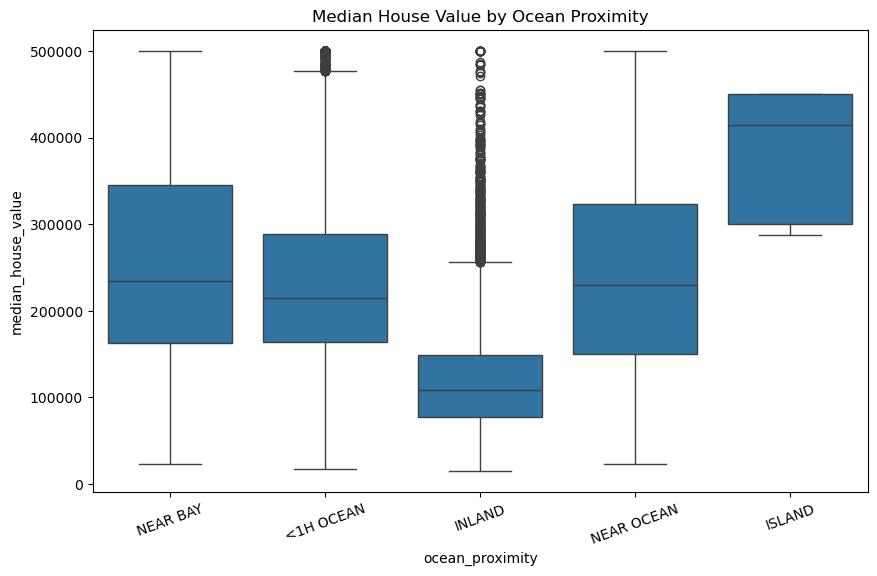

In [144]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="ocean_proximity",
    y="median_house_value",
    data=df
)

plt.xticks(rotation=20)
plt.title("Median House Value by Ocean Proximity")
plt.show()

# Phase 2: Exploratory Data Analysis (EDA)

## Histograms

- Most numerical features are **right-skewed**, especially `total_rooms`, `total_bedrooms`, `population`, and `median_income`.
- `housing_median_age` appears to be capped at **52 years**, suggesting an upper limit in the dataset.
- `median_house_value` is capped around **500,000**, indicating that house prices may have been limited during data collection.
- The distributions of several features are not normal and contain potential outliers.

---

## Geographic Scatter Plot

- The scatter plot resembles the map of California.
- Houses with higher median values are mainly concentrated along the **coastal regions**, particularly near San Francisco and Los Angeles.
- Inland areas generally have lower house prices.
- This suggests that **location is an important factor** affecting house prices.

---

## Correlation Matrix

- `median_income` has the **strongest positive correlation** with `median_house_value`.
- `housing_median_age` has a weak positive correlation with house prices.
- `latitude` and `longitude` show relatively weak correlations individually, although together they capture geographic location.
- Features such as `total_rooms`, `population`, and `households` have only weak to moderate correlations with the target.

---

## Ocean Proximity Analysis

- Houses located **NEAR BAY** and **<1H OCEAN** generally have higher median house values.
- **INLAND** houses tend to have lower house values.
- The box plot shows that house prices vary significantly across different ocean proximity categories.
- This indicates that `ocean_proximity` is an important categorical feature for predicting house prices.

---

## Summary

From the exploratory analysis, we observed missing values, skewed distributions, capped values, possible outliers, and strong geographic patterns. Among all features, **median_income** appears to be the most influential predictor of **median_house_value**, while **location** and **ocean_proximity** also have a significant impact on housing prices.

# Phase 3 — Data Cleaning & Preprocessing


In [145]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [146]:
df.isnull().mean()

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        0.010029
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

## As mean value was 0.01 < 0.5 thus we kept this column

In [147]:
median=df['total_bedrooms'].median()
df["total_bedrooms"].fillna(median, inplace=True)

# Handling Missing Values

The `total_bedrooms` column contains **207 missing values** out of **20,640** records.

To handle these missing values, I used **median imputation** instead of dropping the rows. The median is more robust to outliers than the mean, making it a suitable choice for this feature. Since only about **1%** of the data is missing, filling the missing values allows us to retain all observations while minimizing the impact on the dataset.

**Method Used:** Median Imputation

In [148]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

### Encoding Categorical Features

The `ocean_proximity` column is categorical.

Machine learning models cannot directly process text values, so One-Hot Encoding was applied to convert categories into binary indicator variables while avoiding any artificial ordering.

In [149]:
pd.get_dummies(df,columns=['ocean_proximity'],drop_first=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,True,False,False,False
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,True,False,False,False
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,True,False,False,False
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,True,False,False,False


In [150]:
df["rooms_per_household"] = (
    df["total_rooms"] / df["households"]
)

In [151]:
df["bedrooms_per_room"] = (
    df["total_bedrooms"] / df["total_rooms"]
)

In [152]:
df["population_per_household"] = (
    df["population"] / df["households"]
)

In [153]:
from sklearn.model_selection import train_test_split

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   total_rooms               20640 non-null  float64
 4   total_bedrooms            20640 non-null  float64
 5   population                20640 non-null  float64
 6   households                20640 non-null  float64
 7   median_income             20640 non-null  float64
 8   median_house_value        20640 non-null  float64
 9   ocean_proximity           20640 non-null  object 
 10  rooms_per_household       20640 non-null  float64
 11  bedrooms_per_room         20640 non-null  float64
 12  population_per_household  20640 non-null  float64
dtypes: float64(12), object(1)
memory usage: 2.0+ MB


In [155]:
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY,4.761658,0.231774,2.139896
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY,4.931907,0.192899,2.128405
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY,4.797527,0.221327,1.788253
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY,4.294118,0.260274,2.026891
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY,4.970588,0.199211,2.172269


In [156]:
# Features and Target
ocean_dummies = pd.get_dummies(df["ocean_proximity"], prefix="ocean_proximity")
df = pd.concat([df, ocean_dummies], axis=1)
X = df.drop(["median_house_value", "ocean_proximity"], axis=1) 

y = df["median_house_value"]

In [157]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


### Feature Scaling

StandardScaler was applied because Linear Regression performs better when numerical features are on similar scales.

The scaler standardizes every feature using:

\[
z=\frac{x-\mu}{\sigma}
\]

where

- μ = mean
- σ = standard deviation

In [158]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# Phase 4 — Model Training


In [159]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
y_pred = lin_model.predict(X_test_scaled)

# Phase 5 — Evaluation


In [160]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
mse = mean_squared_error(y_test, y_pred)
print(f"MSE (Mean Squared Error): {mse:.3f}")

R2: 0.5970176824350766
MAE: 50888.66001572007
RMSE: 72668.53837868222
MSE (Mean Squared Error): 5280716470.094


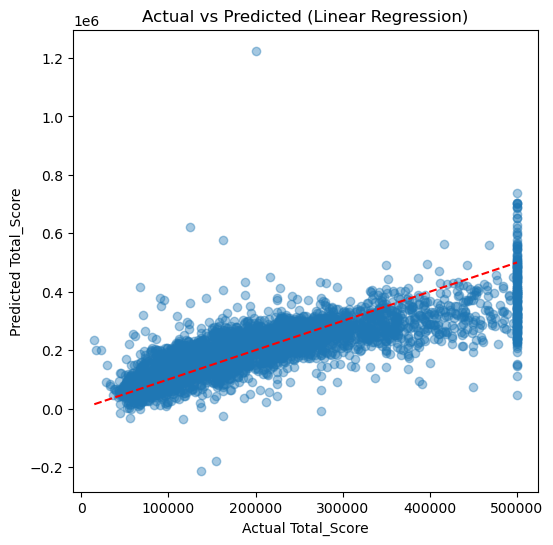

In [161]:
# Actual vs Predicted plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Total_Score')
plt.ylabel('Predicted Total_Score')
plt.title('Actual vs Predicted (Linear Regression)')
plt.show()

## Phase 6 — Prediction Demo


In [162]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [163]:
def predict_house_value(
    longitude, latitude, housing_median_age,
    total_rooms, total_bedrooms, population,
    households, median_income, ocean_proximity
):
    # derived features   -> 
    rooms_per_household = total_rooms / households
    bedrooms_per_room = total_bedrooms / total_rooms
    population_per_household = population / households

    # base numeric features
    sample = {
        "longitude": longitude,
        "latitude": latitude,
        "housing_median_age": housing_median_age,
        "total_rooms": total_rooms,
        "total_bedrooms": total_bedrooms,
        "population": population,
        "households": households,
        "median_income": median_income,
        "rooms_per_household": rooms_per_household,
        "bedrooms_per_room": bedrooms_per_room,
        "population_per_household": population_per_household,
    }

   
    ocean_categories = ["<1H OCEAN", "INLAND", "ISLAND", "NEAR BAY", "NEAR OCEAN"]
    for cat in ocean_categories:
        col_name = f"ocean_proximity_{cat}"
        sample[col_name] = 1 if cat == ocean_proximity else 0

    sample_df = pd.DataFrame([sample])

    # this line is for ,the column are trained in a order,same order we create for testing
    sample_df = sample_df[X_train.columns]

    
    sample_scaled = scaler.transform(sample_df)

    
    prediction = lin_model.predict(sample_scaled)
    # As only one sample thus one element in  prediction array
    return prediction[0]



predicted_value = predict_house_value(
    longitude=-122.23,
    latitude=37.88,
    housing_median_age=41,
    total_rooms=880,
    total_bedrooms=129,
    population=322,
    households=126,
    median_income=8.3252,
    ocean_proximity="NEAR BAY"
)

print(f"Predicted House Value: ${predicted_value:,.2f}")



Predicted House Value: $407,358.61
